# Análise e Classificação de Câncer de Mama

In [ ]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Exporting models
import pickle
from pathlib import Path

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

Machine Learning para Classificação de Câncer de Mama

Este notebook tem como objetivo principal o desenvolvimento de modelos de Machine Learning para a classificação de câncer de mama, utilizando o dataset Wisconsin Diagnostic Breast Cancer. As etapas incluem a exploração dos dados, pré-processamento, engenharia de atributos, treinamento de diversos modelos e avaliação de desempenho.

In [80]:
pd.set_option('display.max_columns', None)

## 1. Carregamento e Visão Geral dos Dados

Nesta seção, carregamos o dataset `breast-cancer-wisconsin-data.csv` em um DataFrame do Pandas e realizamos uma inspeção inicial para entender sua estrutura, dimensões e as primeiras linhas dos dados.

In [81]:
df = pd.read_csv("../data/breast-cancer-wisconsin-data.csv")

In [82]:
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 569 rows × 33 columns


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Verificamos o formato geral do DataFrame (número de linhas e colunas) e listamos os nomes das colunas para ter uma visão completa dos atributos disponíveis.

In [83]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [84]:
print("Formato:", df.shape)
print("Colunas:", list(df.columns))

Formato: (569, 33)
Colunas: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


O método `info()` fornece um resumo conciso do DataFrame, incluindo o tipo de dado de cada coluna e o número de valores não nulos. Isso é crucial para identificar colunas com dados ausentes ou tipos de dados incorretos.

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

## 2. Análise Exploratória de Dados (EDA) e Pré-processamento Inicial

### Resumo Estatístico

Geramos um resumo estatístico para todas as colunas numéricas, o que nos ajuda a entender a distribuição dos dados, identificar possíveis outliers e a escala de cada atributo.

In [86]:
# Resumo estatístico
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
id,569.000000,30371831.432337,125020585.612224,8670.000000,869218.000000,906024.000000,8813129.000000,911320502.000000
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000


### Tratamento de Valores Ausentes

Identificamos a quantidade e a porcentagem de valores nulos em cada coluna. A coluna 'Unnamed: 32' possui 100% de valores nulos, sendo um bom candidato para remoção.

In [87]:
# Valores em falta / nulos
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({"Qtd. de Nulos": missing, "Nulos %": missing_pct})
missing_df = missing_df[missing_df["Qtd. de Nulos"] > 0].sort_values("Qtd. de Nulos", ascending=False)

print(f"Total de valores em nulos no dataset: {df.isnull().sum().sum()}")
missing_df


Total de valores em nulos no dataset: 569


,Qtd. de Nulos,Nulos %
Unnamed: 32,569,100.0


### Verificação de Duplicatas

É importante verificar se há linhas duplicadas no dataset, pois elas podem introduzir viés nos modelos.

In [88]:
# Linhas duplicadas
duplicate_count = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicate_count}")

Número de linhas duplicadas: 0


### Distribuição da Variável Alvo (`diagnosis`)

Analisamos a distribuição das classes (benigno e maligno) na variável alvo (`diagnosis`). Uma distribuição desequilibrada pode requerer técnicas de balanceamento de classes.

diagnosis
B    357
M    212
Name: count, dtype: int64

Class balance: {'B': 62.7, 'M': 37.3}


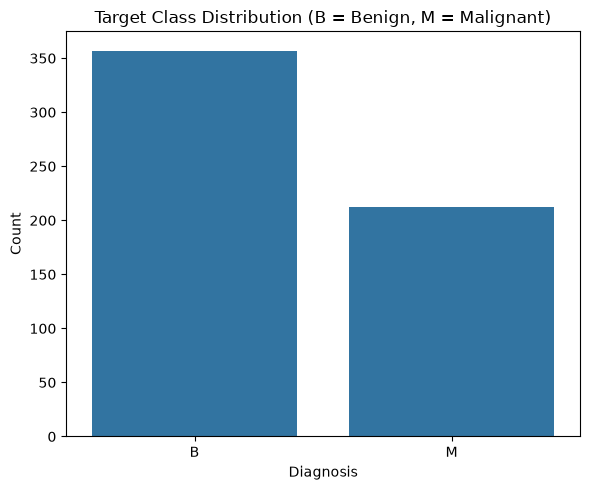

In [89]:
# Distribuição por classes
class_counts = df["diagnosis"].value_counts()
print(class_counts)
print(f"\nClass balance: {(class_counts / class_counts.sum() * 100).round(1).to_dict()}")

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="diagnosis", order=["B", "M"])
plt.title("Target Class Distribution (B = Benign, M = Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Heatmap de Correlação

Um heatmap de correlação para as features de 'mean' (média) nos permite visualizar as relações lineares entre os atributos. Alta correlação entre features pode indicar multicolinearidade, que pode afetar alguns modelos de ML.

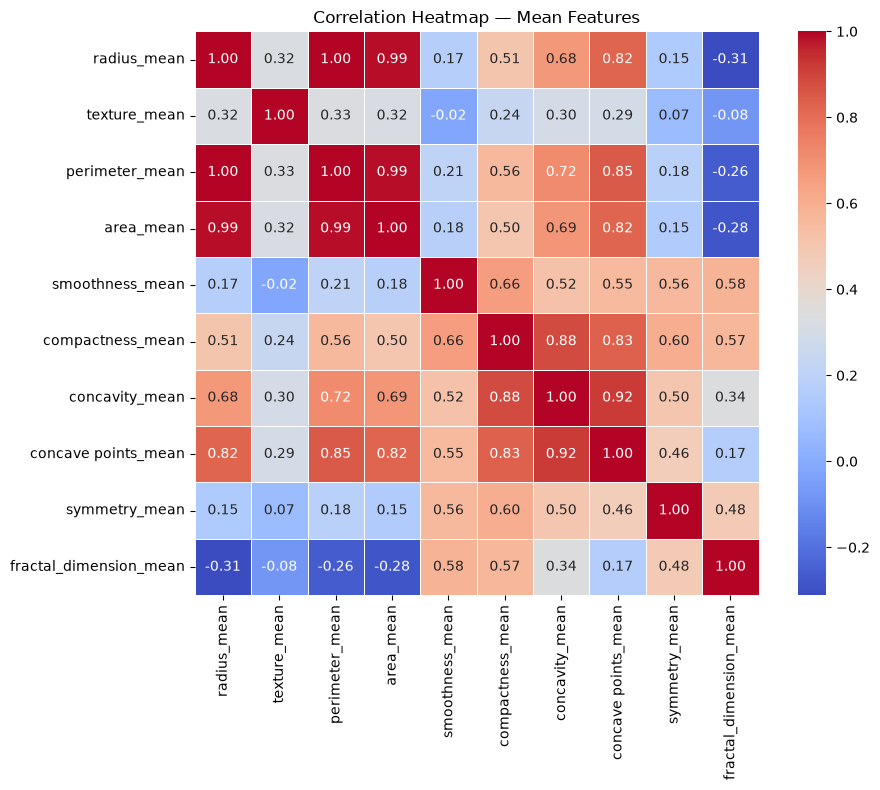

In [90]:
# Correlation Heatmap (Mean Features)
mean_features = [c for c in df.columns if c.endswith("_mean")]

plt.figure(figsize=(10, 8))
corr = df[mean_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Mean Features")
plt.tight_layout()
plt.show()


### Distribuições das Características por Diagnóstico

Visualizamos a distribuição de algumas características-chave ('radius_mean', 'texture_mean', 'concavity_mean', 'area_mean') separadas pelo diagnóstico (benigno ou maligno). Isso nos ajuda a entender como cada característica se comporta em relação à classe alvo.

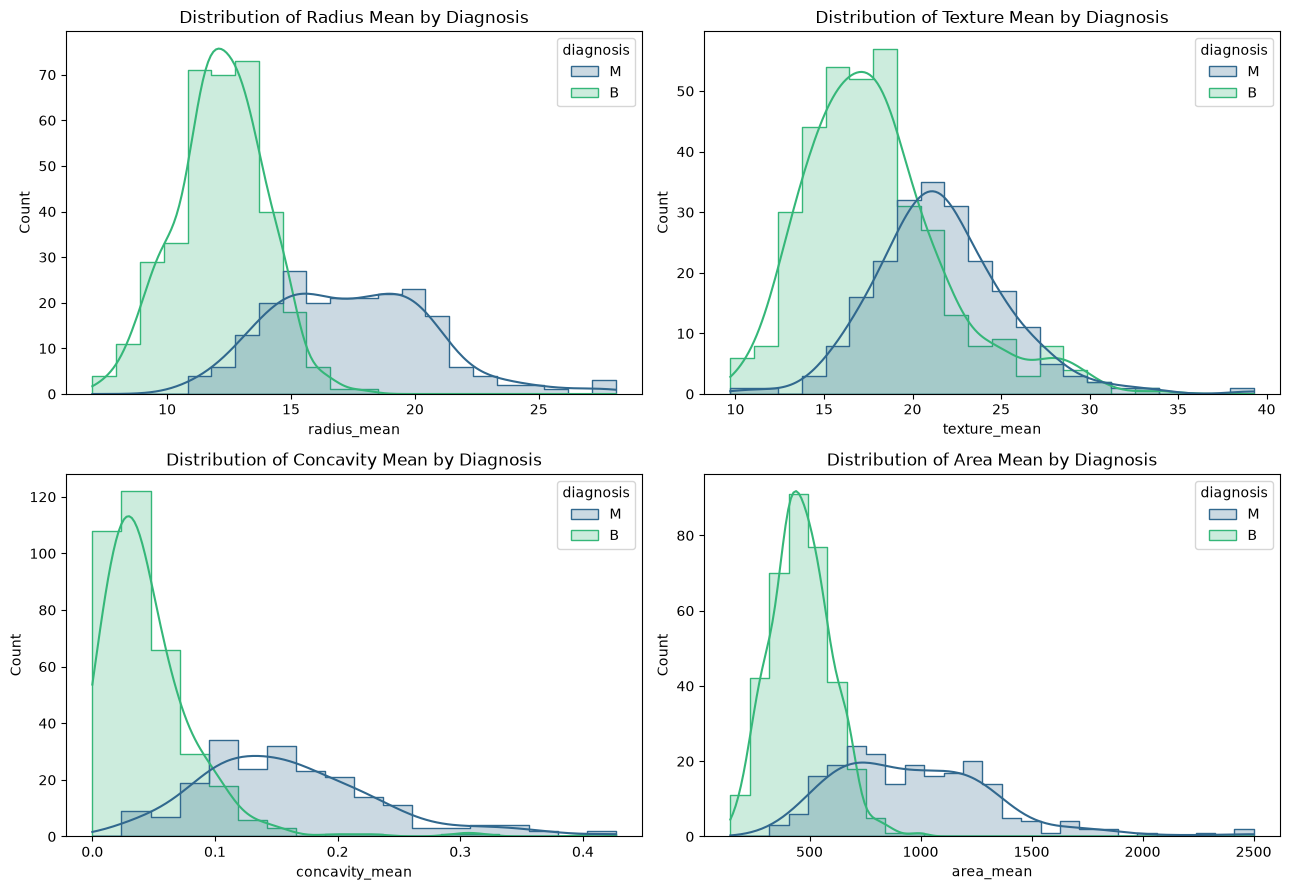

In [91]:
# Distribuições das características por diagnóstico
key_features = ["radius_mean", "texture_mean", "concavity_mean", "area_mean"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), key_features):
    sns.histplot(data=df, x=col, hue="diagnosis", kde=True, palette="viridis", element="step", ax=ax)
    ax.set_title(f"Distribution of {col.replace('_', ' ').title()} by Diagnosis")

plt.tight_layout()
plt.show()

### Boxplots para Características-Chave

Os boxplots fornecem uma visão da distribuição de cada característica para cada classe de diagnóstico, ajudando a identificar diferenças nas medianas, quartis e a presença de outliers.

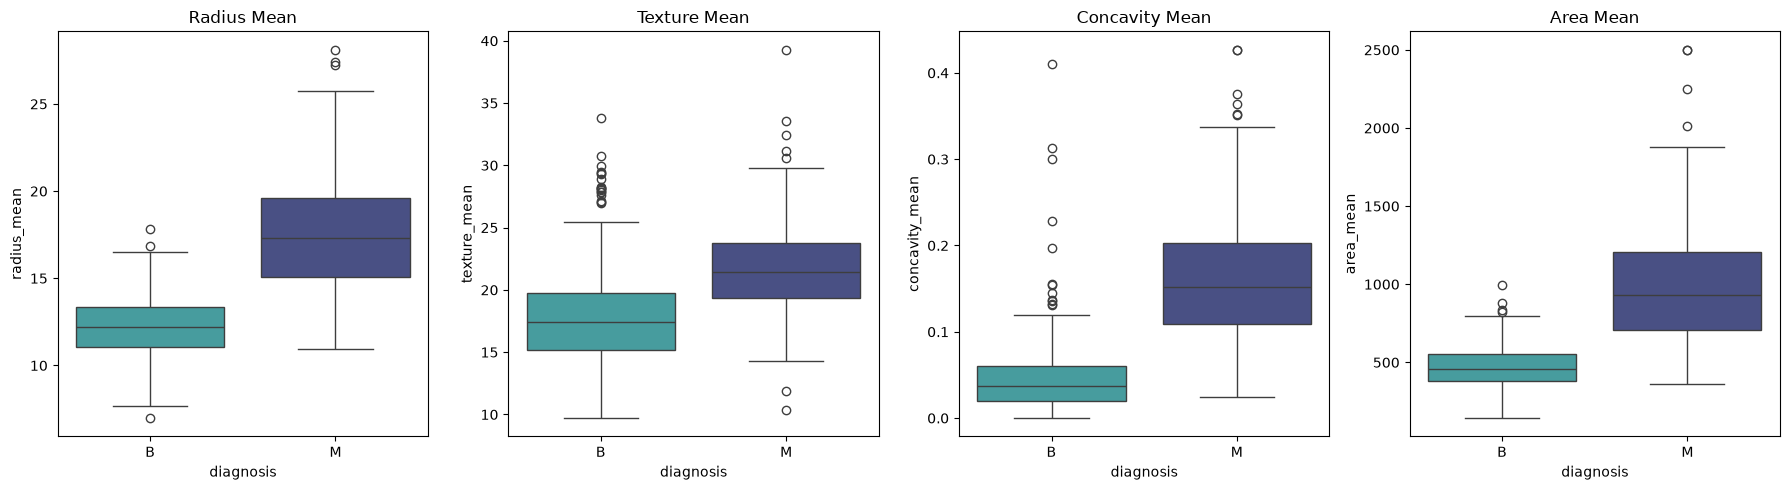

In [92]:
# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, key_features):
    sns.boxplot(data=df, x="diagnosis", y=col, order=["B", "M"], hue="diagnosis", palette="mako", ax=ax)
    ax.set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

### Pairplot de Características-Chave

O pairplot mostra a relação entre pares de características, com as distribuições de cada característica na diagonal. A coloração por diagnóstico ajuda a visualizar a separabilidade das classes.

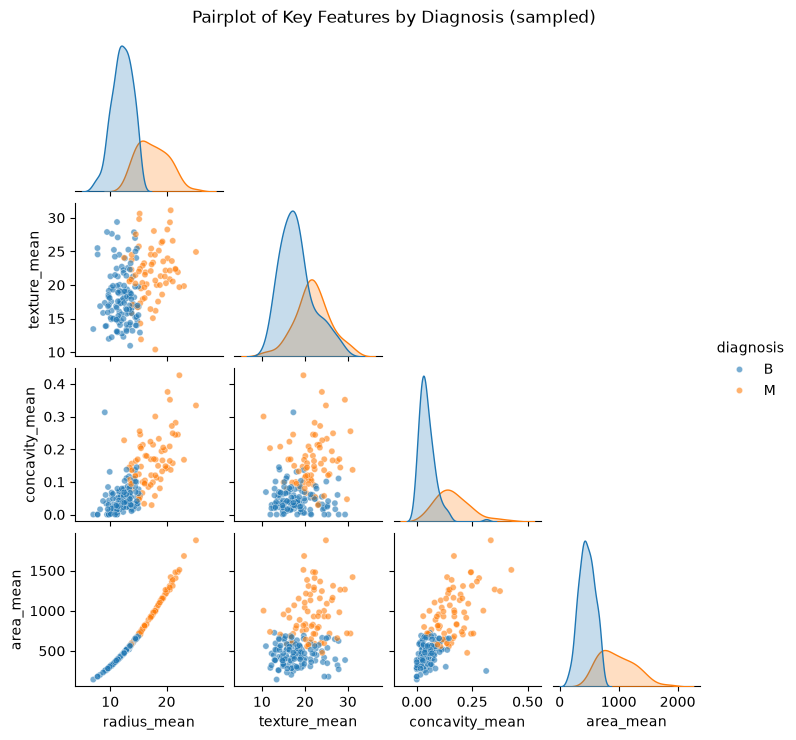

In [93]:
# Pairplot
pair_cols = ["radius_mean", "texture_mean", "concavity_mean", "area_mean", "diagnosis"]
sample_df = df[pair_cols].sample(min(200, len(df)), random_state=42)

sns.pairplot(sample_df, hue="diagnosis", corner=True,
             height=1.8, plot_kws={"alpha": 0.6, "s": 20})
plt.suptitle("Pairplot of Key Features by Diagnosis (sampled)", y=1.02)
plt.show()

## 3. Limpeza e Engenharia de Atributos

Nesta etapa, realizamos a limpeza final dos dados e preparamos os atributos para o treinamento dos modelos de Machine Learning. Isso inclui a remoção de colunas desnecessárias e a codificação da variável alvo.

In [94]:
# Lindando os dados
df.drop(['Unnamed: 32','id'],  axis=1,inplace=True)

# Encode target: maligno = 1 (classe positiva), benigno = 0
label_encoder = LabelEncoder()
df["diagnosis"] = label_encoder.fit_transform(df["diagnosis"])  # B=0, M=1

print(f"Dataset shape (Current): {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape (Current): 569 rows × 31 columns


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Confirmamos que não há mais valores nulos após a remoção da coluna 'Unnamed: 32'.

In [95]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

### Separação de Features e Target

Dividimos o dataset em matriz de features (X) e vetor de target (y). A variável `diagnosis` (diagnóstico) é o nosso alvo de predição.

In [96]:
# Feature Engineering

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Feature matrix X:", X.shape)
print("Target vector y :", y.shape)
print(f"Positive class (malignant) rate: {y.mean():.2%}")


Feature matrix X: (569, 30)
Target vector y : (569,)
Positive class (malignant) rate: 37.26%


### Divisão entre Conjuntos de Treino e Teste

Dividimos os dados em conjuntos de treino e teste para avaliar o desempenho do modelo em dados não vistos. A estratificação (`stratify=y`) garante que a proporção das classes seja mantida em ambos os conjuntos.

In [97]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows  |  Malignant rate: {y_train.mean():.2%}")
print(f"Test set    : {X_test.shape[0]:,} rows  |  Malignant rate: {y_test.mean():.2%}")


Training set: 455 rows  |  Malignant rate: 37.36%
Test set    : 114 rows  |  Malignant rate: 36.84%


### Escalonamento de Features (StandardScaler)

Utilizamos o `StandardScaler` para padronizar as features, transformando-as para que tenham média zero e desvio padrão um. Isso é crucial para muitos algoritmos de Machine Learning que são sensíveis à escala dos dados.

In [98]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print(" Features scaled. Example — before vs. after for 'area_mean':")
print(f"   Before: mean={X_train['area_mean'].mean():.2f}, std={X_train['area_mean'].std():.2f}")
print(f"   After : mean={X_train_scaled['area_mean'].mean():.2f}, std={X_train_scaled['area_mean'].std():.2f}")

 Features scaled. Example — before vs. after for 'area_mean':
   Before: mean=659.58, std=360.42
   After : mean=-0.00, std=1.00


## 4. Treinamento e Avaliação de Modelos Base

Nesta seção, treinamos e avaliamos vários modelos de classificação utilizando os dados escalonados. A função `evaluate_metrics` é definida para padronizar a avaliação de cada modelo.

In [99]:
# Avaliação de modelos
results = []  # recolhe um dicionário por modelo

def evaluate_metrics(model, model_name, X_test, y_test, results_list=results):
    """
    Avalia um modelo já treinado e exibe suas métricas.
    """

    # Predições
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    # Salvar resultados
    results_list.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    # Exibir resultados
    print("-" * 45)
    print(f"📌 {model_name}")
    print("-" * 45)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("-" * 45)

### Regressão Logística

O modelo de Regressão Logística é treinado e suas métricas de desempenho são avaliadas.

In [100]:
# Model Training

# 1º Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

evaluate_metrics(log_reg, "Logistic Regression", X_test_scaled, y_test)

---------------------------------------------
📌 Logistic Regression
---------------------------------------------
Accuracy  : 0.9649
Precision : 0.9750
Recall    : 0.9286
F1 Score  : 0.9512
ROC-AUC   : 0.9960
Confusion Matrix:
[[71  1]
 [ 3 39]]
---------------------------------------------


### Random Forest

O modelo Random Forest, um ensemble de árvores de decisão, é treinado e avaliado.

In [101]:
# 2º Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

evaluate_metrics(rf, "Random Forest", X_test_scaled, y_test)

---------------------------------------------
📌 Random Forest
---------------------------------------------
Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1 Score  : 0.9630
ROC-AUC   : 0.9929
Confusion Matrix:
[[72  0]
 [ 3 39]]
---------------------------------------------


### K-Nearest Neighbors (KNN)

O modelo K-Nearest Neighbors é treinado e avaliado. Este algoritmo classifica um ponto de dados com base na maioria dos votos de seus vizinhos mais próximos.

In [102]:
# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

evaluate_metrics(knn, "K-Nearest Neighbors", X_test_scaled, y_test)

---------------------------------------------
📌 K-Nearest Neighbors
---------------------------------------------
Accuracy  : 0.9561
Precision : 0.9744
Recall    : 0.9048
F1 Score  : 0.9383
ROC-AUC   : 0.9823
Confusion Matrix:
[[71  1]
 [ 4 38]]
---------------------------------------------


### Comparação de Modelos Base

Comparamos os resultados dos modelos treinados até agora, ordenando-os pela acurácia para identificar os melhores desempenhos.

In [103]:
# Model Comparison
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
comparison_df.index += 1

comparison_df.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"], cmap="Greens"
).format({"Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
          "F1 Score": "{:.4f}", "ROC-AUC": "{:.4f}"})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929
2,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
3,K-Nearest Neighbors,0.9561,0.9744,0.9048,0.9383,0.9823


Visualizamos as métricas de desempenho para cada modelo base em gráficos de barras para facilitar a comparação.

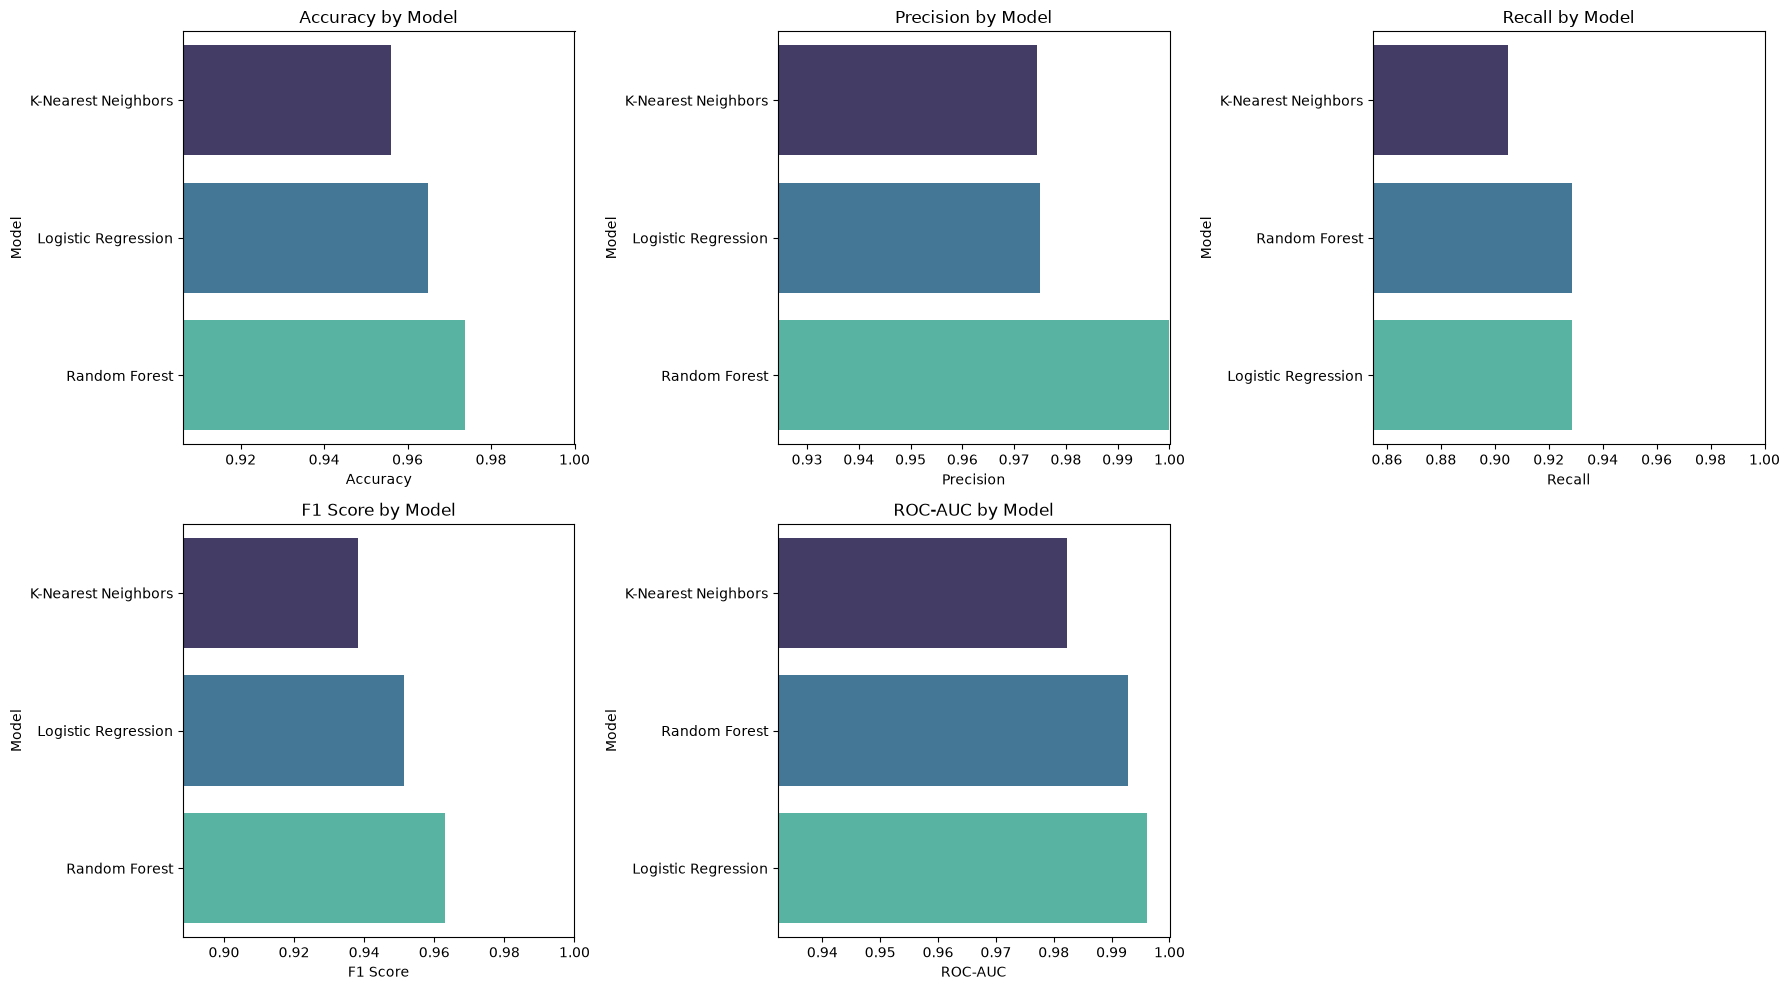

In [104]:
#Metric Comparison Bar Charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_list = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

for ax, metric in zip(axes.flatten(), metrics_list):
    sorted_df = comparison_df.sort_values(metric, ascending=True)
    sns.barplot(data=sorted_df, x=metric, y="Model", hue="Model", palette="mako", legend=False, ax=ax)
    ax.set_title(f"{metric} by Model")
    ax.set_xlim(sorted_df[metric].min() - 0.05, 1.0)

axes.flatten()[-1].axis("off")  # unused 6th subplot
plt.tight_layout()
plt.show()

## 5. Otimização com RobustScaler e PCA

Nesta seção, exploramos a utilização do `RobustScaler` para um escalonamento mais robusto a outliers e a aplicação do Principal Component Analysis (PCA) para redução de dimensionalidade. Em seguida, reavaliamos os modelos com esses pré-processamentos.

### RobustScaler

O `RobustScaler` é utilizado para escalar os dados usando a mediana e o Intervalo Interquartil (IQR), tornando-o mais resistente a outliers em comparação com o `StandardScaler`.

In [105]:
# Normalização robusta baseada na mediana
robust_scaler = RobustScaler()

X_train_robust = pd.DataFrame(
    robust_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_robust = pd.DataFrame(
    robust_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Dados normalizados utilizando mediana/IQR.")
print("Treino:", X_train_robust.shape)
print("Teste :", X_test_robust.shape)

Dados normalizados utilizando mediana/IQR.
Treino: (455, 30)
Teste : (114, 30)


### Principal Component Analysis (PCA)

Aplicamos PCA para reduzir a dimensionalidade dos dados, mantendo 95% da variância explicada. Isso pode ajudar a reduzir o tempo de treinamento do modelo e mitigar o risco de overfitting.

In [106]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_robust)
X_test_pca = pca.transform(X_test_robust)

print("Número de componentes originais:", X_train_robust.shape[1])
print("Número de componentes após PCA:", X_train_pca.shape[1])

print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.2%}")

Número de componentes originais: 30
Número de componentes após PCA: 10
Variância explicada: 95.66%


Visualizamos a variância explicada acumulada pelos componentes principais, confirmando que 10 componentes capturam mais de 95% da variância total.

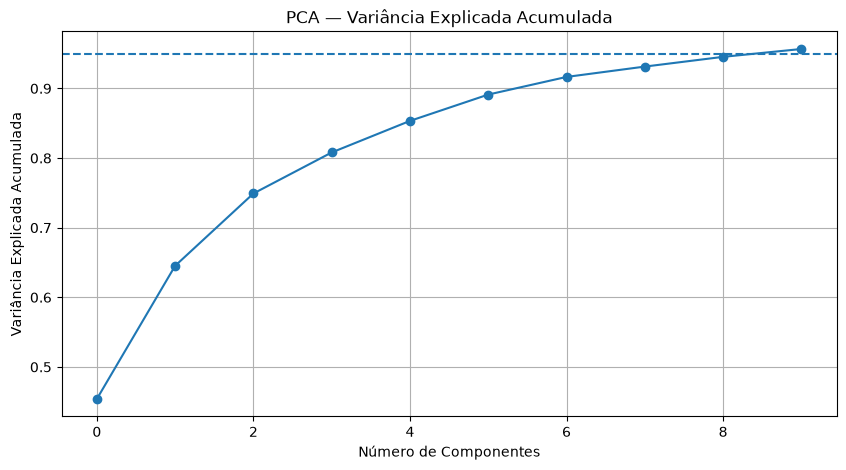

In [107]:
plt.figure(figsize=(10, 5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.xlabel("Número de Componentes")
plt.ylabel("Variância Explicada Acumulada")
plt.title("PCA — Variância Explicada Acumulada")

plt.grid(True)
plt.show()

In [108]:
X_train_pca_df = pd.DataFrame(X_train_pca, index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca, index=X_test.index)

### Regressão Logística com RobustScaler e PCA

Treinamos e avaliamos o modelo de Regressão Logística novamente, desta vez utilizando os dados transformados pelo `RobustScaler` e PCA.

In [109]:
log_reg_pca = LogisticRegression(
    random_state=42,
    max_iter=5000
)

log_reg_pca.fit(
    X_train_pca_df,
    y_train
)

evaluate_metrics(
    log_reg_pca,
    "Logistic Regression + RobustScaler + PCA",
    X_test_pca_df,
    y_test
)

---------------------------------------------
📌 Logistic Regression + RobustScaler + PCA
---------------------------------------------
Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1 Score  : 0.9630
ROC-AUC   : 0.9974
Confusion Matrix:
[[72  0]
 [ 3 39]]
---------------------------------------------


### Random Forest com RobustScaler e PCA

Treinamos e avaliamos o modelo Random Forest com os dados transformados.

In [110]:
rf_pca = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_pca.fit(
    X_train_pca_df,
    y_train
)

evaluate_metrics(
    rf_pca,
    "Random Forest + RobustScaler + PCA",
    X_test_pca_df,
    y_test
)

---------------------------------------------
📌 Random Forest + RobustScaler + PCA
---------------------------------------------
Accuracy  : 0.9386
Precision : 0.9487
Recall    : 0.8810
F1 Score  : 0.9136
ROC-AUC   : 0.9854
Confusion Matrix:
[[70  2]
 [ 5 37]]
---------------------------------------------


### K-Nearest Neighbors (KNN) com RobustScaler e PCA

Treinamos e avaliamos o modelo KNN com os dados transformados.

In [111]:
knn_pca = KNeighborsClassifier()

knn_pca.fit(
    X_train_pca_df,
    y_train
)

evaluate_metrics(
    knn_pca,
    "KNN + RobustScaler + PCA",
    X_test_pca_df,
    y_test
)

---------------------------------------------
📌 KNN + RobustScaler + PCA
---------------------------------------------
Accuracy  : 0.9386
Precision : 0.9730
Recall    : 0.8571
F1 Score  : 0.9114
ROC-AUC   : 0.9823
Confusion Matrix:
[[71  1]
 [ 6 36]]
---------------------------------------------


## 6. Comparação Final de Modelos


### Comparação de Todos os Modelos
Nesta seção, realizamos uma comparação abrangente de todos os modelos avaliados, incluindo tanto os modelos base quanto aqueles otimizados com `RobustScaler` e PCA.



In [112]:
comparison_all = pd.DataFrame(results)

display(
    comparison_all[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ].sort_values("Accuracy", ascending=False)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890
3,Logistic Regression + RobustScaler + PCA,0.973684,1.000000,0.928571,0.962963,0.997354
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
2,K-Nearest Neighbors,0.956140,0.974359,0.904762,0.938272,0.982308
4,Random Forest + RobustScaler + PCA,0.938596,0.948718,0.880952,0.913580,0.985450
5,KNN + RobustScaler + PCA,0.938596,0.972973,0.857143,0.911392,0.982308


### Comparação de Modelos com PCA

Focamos na comparação dos modelos que utilizaram PCA, para analisar o impacto da redução de dimensionalidade.

In [113]:
pca_comparison = comparison_all[
    comparison_all["Model"].str.contains("PCA")
].copy()

pca_comparison = pca_comparison.sort_values(
    "Accuracy",
    ascending=False
)

display(
    pca_comparison[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ]
)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Logistic Regression + RobustScaler + PCA,0.973684,1.000000,0.928571,0.962963,0.997354
4,Random Forest + RobustScaler + PCA,0.938596,0.948718,0.880952,0.913580,0.985450
5,KNN + RobustScaler + PCA,0.938596,0.972973,0.857143,0.911392,0.982308


### Gráfico de Barras de Acurácia

Visualizamos a acurácia de todos os modelos em um gráfico de barras, o que facilita a identificação visual dos modelos com melhor desempenho.

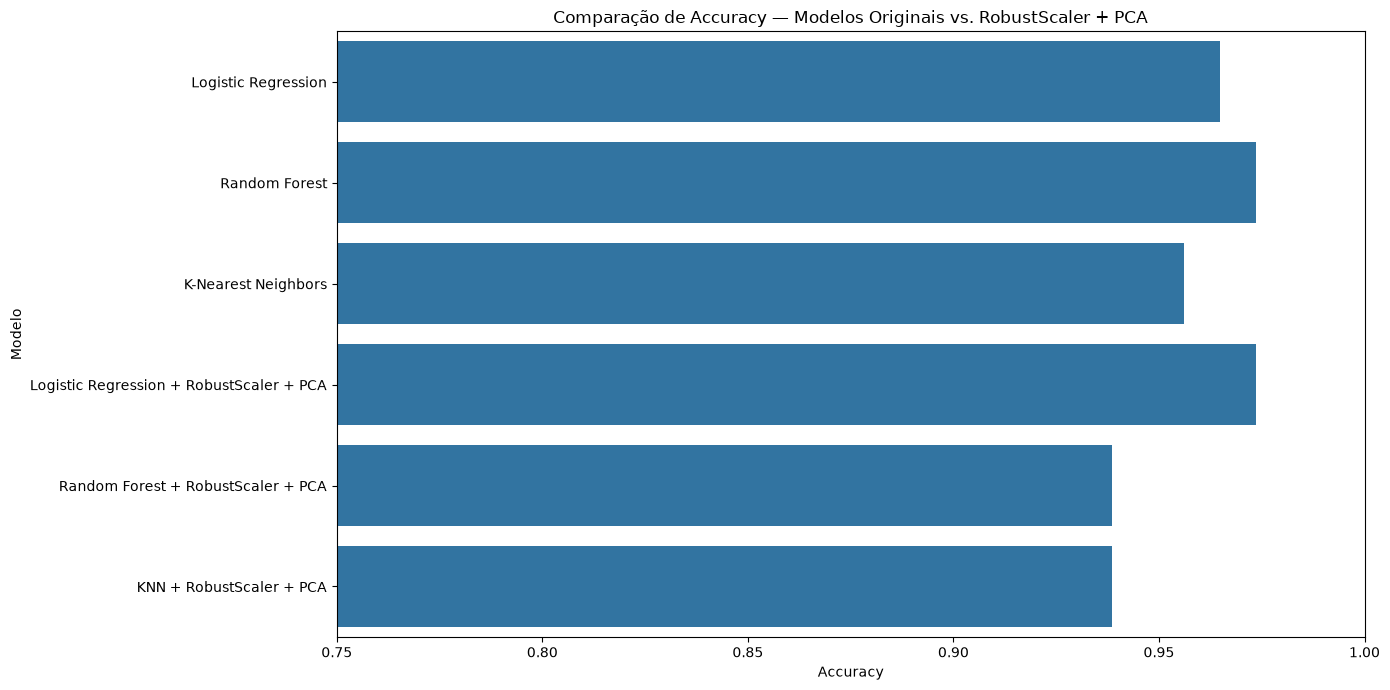

In [114]:
comparison_final = pd.DataFrame(results)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=comparison_final,
    x="Accuracy",
    y="Model"
)

plt.title("Comparação de Accuracy — Modelos Originais vs. RobustScaler + PCA")
plt.xlabel("Accuracy")
plt.ylabel("Modelo")
plt.xlim(0.75, 1.0)

plt.tight_layout()
plt.show()

### Análise Comparativa das Matrizes de Confusão e Relatórios de Classificação

Abaixo, apresentamos as matrizes de confusão e os relatórios de classificação para todos os modelos treinados, tanto os modelos base (com `StandardScaler`) quanto os modelos otimizados com `RobustScaler` e PCA. Esta seção visa fornecer uma visão detalhada dos **Verdadeiros Positivos (VP)**, **Verdadeiros Negativos (VN)**, **Falsos Positivos (FP)** e **Falsos Negativos (FN)**.

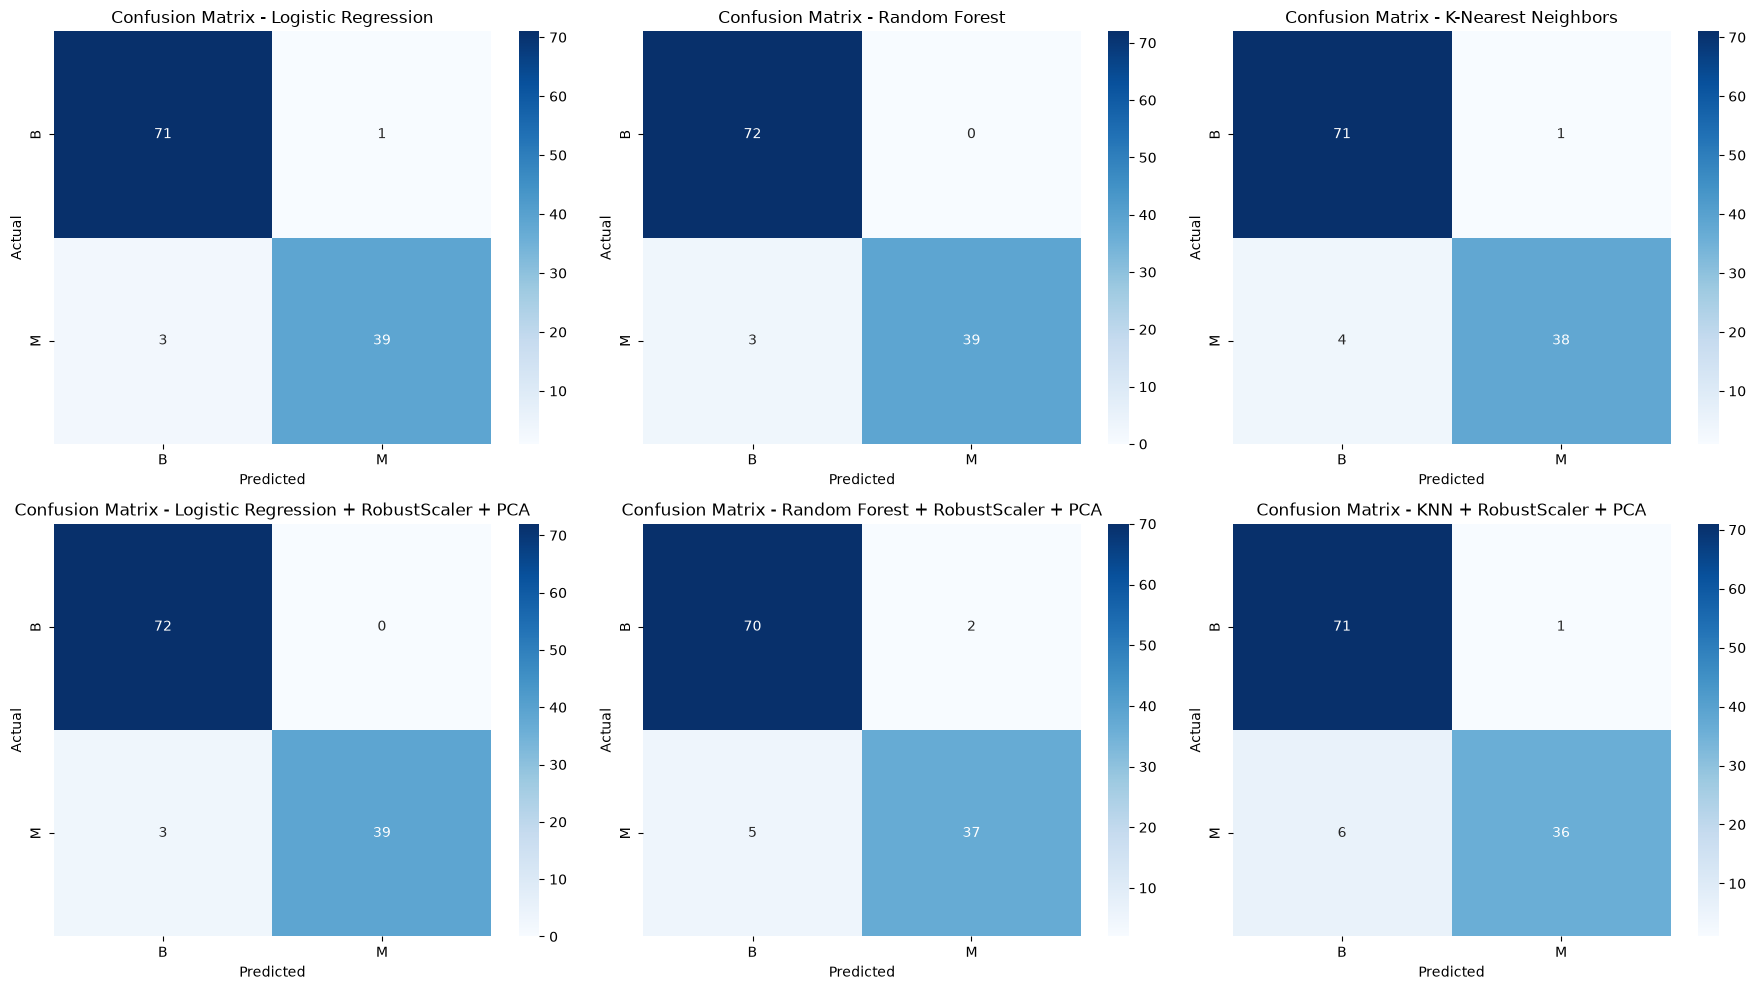

In [115]:
all_models_dict = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf, X_test_scaled),
    "K-Nearest Neighbors": (knn, X_test_scaled),
    "Logistic Regression + RobustScaler + PCA": (log_reg_pca, X_test_pca_df),
    "Random Forest + RobustScaler + PCA": (rf_pca, X_test_pca_df),
    "KNN + RobustScaler + PCA": (knn_pca, X_test_pca_df),
}

num_models = len(all_models_dict)
rows = (num_models + 2) // 3 # Adjust rows to fit models (max 3 cols)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
axes = axes.flatten()

for i, (name, (model, test_data)) in enumerate(all_models_dict.items()):
    y_pred = model.predict(test_data)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
                ax=axes[i])
    axes[i].set_title(f"Confusion Matrix - {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Análise da Matriz de Confusão e Relatório de Classificação do Melhor Modelo Apresentado

Geramos a matriz de confusão e o relatório de classificação para o melhor modelo identificado (neste caso, Random Forest sem PCA), fornecendo uma análise detalhada dos verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos, além de precisão, recall e f1-score.

Matriz de Confusão para Random Forest (sem PCA):


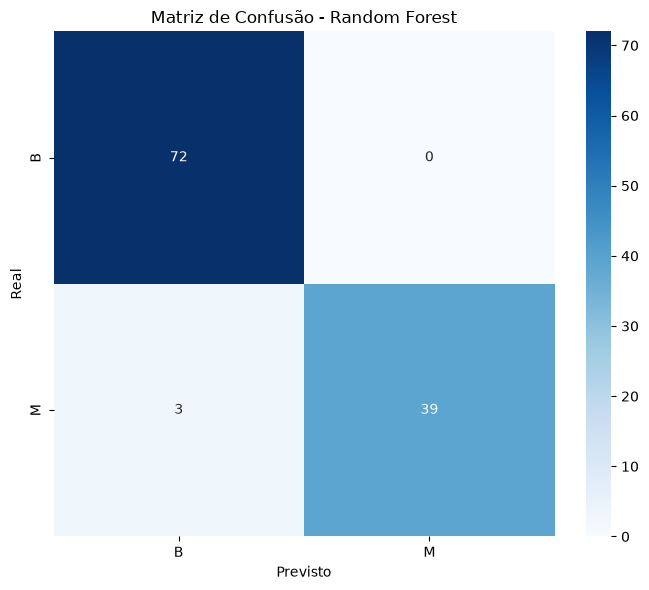


Relatório de Classificação para Random Forest (sem PCA):
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Análise Detalhada:
Verdadeiros Positivos (TP): 39 (Casos de câncer maligno corretamente identificados)
Verdadeiros Negativos (TN): 72 (Casos de câncer benigno corretamente identificados)
Falsos Positivos (FP): 0 (Casos benignos incorretamente classificados como malignos)
Falsos Negativos (FN): 3 (Casos malignos incorretamente classificados como benignos)

Precisão (Maligno): 1.0000 (Proporção de identificações malignas que foram realmente malignas)
Recall (Maligno): 0.9286 (Proporção de casos malignos que foram corretamente identificados)
F1-score (Maligno): 0.9630 (Média harmônica entre precisão e recall p

In [116]:
y_pred_rf = rf.predict(X_test_scaled)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Matriz de Confusão para Random Forest (sem PCA):")
plt.figure(figsize=(7, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print("\nRelatório de Classificação para Random Forest (sem PCA):")
report_rf = classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_, output_dict=True)
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

# Análise detalhada
tn, fp, fn, tp = cm_rf.ravel()

print("\nAnálise Detalhada:")
print(f"Verdadeiros Positivos (TP): {tp} (Casos de câncer maligno corretamente identificados)")
print(f"Verdadeiros Negativos (TN): {tn} (Casos de câncer benigno corretamente identificados)")
print(f"Falsos Positivos (FP): {fp} (Casos benignos incorretamente classificados como malignos)")
print(f"Falsos Negativos (FN): {fn} (Casos malignos incorretamente classificados como benignos)")

print(f"\nPrecisão (Maligno): {report_rf['M']['precision']:.4f} (Proporção de identificações malignas que foram realmente malignas)")
print(f"Recall (Maligno): {report_rf['M']['recall']:.4f} (Proporção de casos malignos que foram corretamente identificados)")
print(f"F1-score (Maligno): {report_rf['M']['f1-score']:.4f} (Média harmônica entre precisão e recall para a classe maligna)")

## Exportando modelos com pickle

In [117]:
def save_model(model, model_name):
    """
    Salva um modelo treinado em um arquivo .pkl dentro do diretório 'models'.
    
    Args:
        model: Modelo treinado (ex: RandomForest, LogisticRegression, etc.)
        model_name (str): Nome do arquivo sem extensão (ex: 'random_forest')
    """
    model_dir = Path("../models")
    model_dir.mkdir(exist_ok=True)
    
    filepath = model_dir / f"model_{model_name}.pkl"
    
    with open(filepath, "wb") as f:
        pickle.dump(model, f)
    
    print(f"✓ Modelo salvo: {filepath}")


save_model(log_reg, "logistic_regression")
save_model(log_reg_pca, "logistic_regression_pca")
save_model(rf, "random_forest")
save_model(rf_pca, "random_forest_pca")
save_model(knn, "knn")
save_model(knn_pca, "knn_pca")

NameError: name 'Path' is not defined

## Conclusão

Com base nas métricas de avaliação, o modelo Random Forest obteve o melhor desempenho na classificação de câncer de mama. A aplicação do RobustScaler e PCA, embora tenha mantido um bom desempenho, não superou os modelos treinados diretamente com as features escalonadas pelo StandardScaler original. Sendo assim, a nossa escolha final.